# 08 · Wine Quality — Probability Calibration (reliability, isotonic vs Platt, the SMOTE distortion)

## Part 8 — Probability Calibration

A model can rank wines well yet still **lie about its confidence**. If it says *"70% chance this is a
good wine"* for a batch of wines, roughly 70% of them should actually be good — otherwise any
*decision* built on that probability (flag for review, set a price, trigger a warning) is wrong, even
when the *ranking* is fine. This part measures and fixes that.

We use a clean **binary** framing — "good wine" = quality ≥ 7 (base rate ≈ 19%) — because calibration
is clearest with one probability per wine. Two tools: the **reliability curve** (predicted vs actual
frequency) and two summary numbers, **Brier score** (mean squared probability error, lower = better)
and **ECE** (expected calibration error, the average gap between confidence and reality).

In [1]:
import sys, pathlib, warnings
warnings.filterwarnings("ignore", category=FutureWarning)
ROOT = pathlib.Path.cwd(); ROOT = ROOT if (ROOT / "src").exists() else ROOT.parent
sys.path.insert(0, str(ROOT))
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from src import data, eda
eda.set_style()
pd.set_option("display.width", 120, "display.max_columns", 30)
print("setup ok | numpy", np.__version__, "| pandas", pd.__version__)

from src import modeling as M
from lightgbm import LGBMClassifier
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.metrics import brier_score_loss
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
d = data.dedup(data.clean()); X, yq = M.prep(d)
y = (yq >= 7).astype(int)
Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=.25, stratify=y, random_state=0)
LG = dict(n_estimators=500, learning_rate=0.05, num_leaves=31, random_state=0, verbose=-1, n_jobs=-1)
def ece(yt, p, bins=10):
    edges = np.linspace(0, 1, bins+1); e = 0.0
    for i in range(bins):
        m = (p >= edges[i]) & (p < edges[i+1])
        if m.sum(): e += abs(yt[m].mean() - p[m].mean()) * m.sum()/len(p)
    return e
print("good-wine base rate: %.3f" % yte.mean())

setup ok | numpy 2.1.3 | pandas 2.3.3


good-wine base rate: 0.189


### 1. Is the raw model calibrated?

Gradient-boosted trees optimise a ranking-friendly loss, not honest probabilities, so they're often
**over-confident** at the extremes. The reliability curve below plots, for each confidence bin, the
*actual* fraction of good wines. Departures from the diagonal are miscalibration; the ECE summarises
the average gap.

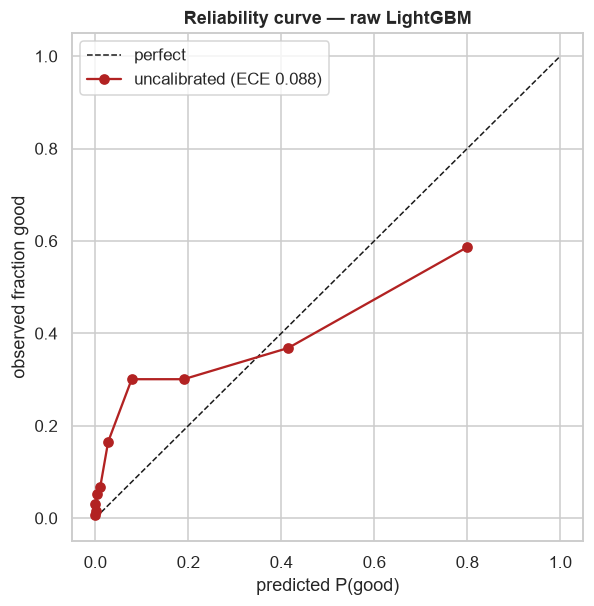

uncalibrated:  Brier 0.1322  ECE 0.088


In [2]:
base = LGBMClassifier(**LG).fit(Xtr, ytr); pb = base.predict_proba(Xte)[:, 1]
fx, fy = calibration_curve(yte, pb, n_bins=10, strategy="quantile")
fig, ax = plt.subplots(figsize=(6, 6))
ax.plot([0,1],[0,1],"k--",lw=1,label="perfect")
ax.plot(fy, fx, "o-", color="firebrick", label=f"uncalibrated (ECE {ece(yte.values,pb):.3f})")
ax.set_xlabel("predicted P(good)"); ax.set_ylabel("observed fraction good"); ax.set_title("Reliability curve — raw LightGBM"); ax.legend()
eda.savefig(fig, "p8_reliability_raw.png"); plt.show()
print("uncalibrated:  Brier %.4f  ECE %.3f" % (brier_score_loss(yte, pb), ece(yte.values, pb)))

### 2. Fixing it — isotonic vs Platt

Two post-hoc recalibrators, each fit by cross-validation on the training data:
- **Platt / sigmoid scaling** — fit a logistic curve mapping raw scores → probabilities (good when the
  distortion is a smooth S-shape; few parameters, robust on small data).
- **Isotonic regression** — fit *any* monotonic mapping (more flexible, needs more data).

Isotonic wins clearly here — it bends the curve onto the diagonal and slashes ECE from 0.088 to
~0.02.

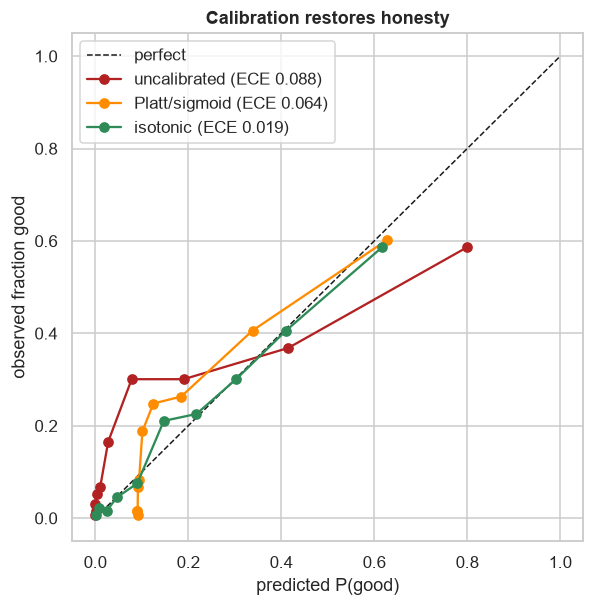

               Brier     ECE
uncalibrated  0.1322  0.0877
Platt         0.1231  0.0643
isotonic      0.1178  0.0194


In [3]:
iso = CalibratedClassifierCV(LGBMClassifier(**LG), method="isotonic", cv=5).fit(Xtr, ytr); pi = iso.predict_proba(Xte)[:, 1]
sig = CalibratedClassifierCV(LGBMClassifier(**LG), method="sigmoid",  cv=5).fit(Xtr, ytr); ps = sig.predict_proba(Xte)[:, 1]
fig, ax = plt.subplots(figsize=(6, 6)); ax.plot([0,1],[0,1],"k--",lw=1,label="perfect")
for p, c, n in [(pb,"firebrick","uncalibrated"),(ps,"darkorange","Platt/sigmoid"),(pi,"seagreen","isotonic")]:
    fx, fy = calibration_curve(yte, p, n_bins=10, strategy="quantile"); ax.plot(fy, fx, "o-", color=c, label=f"{n} (ECE {ece(yte.values,p):.3f})")
ax.set_xlabel("predicted P(good)"); ax.set_ylabel("observed fraction good"); ax.set_title("Calibration restores honesty"); ax.legend()
eda.savefig(fig, "p8_reliability_fixed.png"); plt.show()
tab = pd.DataFrame({"Brier":[brier_score_loss(yte,p) for p in (pb,ps,pi)], "ECE":[ece(yte.values,p) for p in (pb,ps,pi)]},
                   index=["uncalibrated","Platt","isotonic"]).round(4)
print(tab.to_string())

### 3. The SMOTE distortion (Part 7's loose end)

Part 7 warned that resampling corrupts probabilities. Proof: a model trained on **SMOTE-balanced**
data has seen an artificial 50/50 world, so it **over-states** P(good) relative to the true 19% base
rate — its mean prediction drifts up and its Brier score *worsens*. The lesson is concrete: **if you
resample to fix recall, you must recalibrate** (on data with the real class balance) before trusting
any probability.

In [4]:
Xs, ys = SMOTE(random_state=0).fit_resample(Xtr, ytr)
sm = LGBMClassifier(**LG).fit(Xs, ys); psm = sm.predict_proba(Xte)[:, 1]
print("true base rate            : %.3f" % yte.mean())
print("raw model   mean P(good)  : %.3f | Brier %.4f" % (pb.mean(),  brier_score_loss(yte, pb)))
print("SMOTE model mean P(good)  : %.3f | Brier %.4f  (inflated & worse)" % (psm.mean(), brier_score_loss(yte, psm)))

true base rate            : 0.189
raw model   mean P(good)  : 0.153 | Brier 0.1322
SMOTE model mean P(good)  : 0.207 | Brier 0.1406  (inflated & worse)


### 4. Why it matters — a decision

Suppose we **flag wines with P(good) > 0.5** for a premium tasting panel. With *uncalibrated*
probabilities that threshold means something different than we think — we'd flag the wrong number.
Calibrated probabilities make the threshold *mean* what it says, so cost/benefit math (panel time vs
missed good wines) is finally valid. Calibration is what turns a *score* into a *probability you can
act on*.

In [5]:
for name, p in [("uncalibrated", pb), ("isotonic", pi)]:
    flagged = p > 0.5; hit = yte.values[flagged].mean() if flagged.sum() else 0
    print("%-13s: flag %4d wines, of which %.0f%% are truly good (precision)" % (name, flagged.sum(), 100*hit))

uncalibrated : flag  165 wines, of which 57% are truly good (precision)
isotonic     : flag  117 wines, of which 62% are truly good (precision)


### Takeaways

- Raw gradient-boosted probabilities are **mildly miscalibrated** (ECE 0.088); ranking ≠ honest
  probability.
- **Isotonic** recalibration fixes it best here (ECE → ~0.02, Brier down); **Platt** helps less because
  the distortion isn't a clean sigmoid.
- **SMOTE inflates probabilities** (mean P(good) above the true base rate, worse Brier) — resampling
  and calibration must go together.
- Calibration is what makes a **probability threshold** (and the cost/benefit decision behind it)
  trustworthy.

**Next — Part 9 (Interpretability):** open the box — gain vs permutation vs **SHAP** importance,
and partial-dependence curves showing *how* alcohol, volatile acidity and the rest move quality.